In [3]:
import pandas as pd

clean_path = r"E:\archive (6)\budgetwise_finance_dataset.csv"
messy_path = r"E:\archive (6)\budgetwise_synthetic_dirty.csv"

df_clean = pd.read_csv(clean_path)
df_messy = pd.read_csv(messy_path)

print("Clean dataset shape:", df_clean.shape)
print("messy dataset shape:", df_messy.shape)

Clean dataset shape: (15900, 9)
messy dataset shape: (15836, 9)


In [4]:
df_messy.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes'],
      dtype='object')

In [5]:
missing = df_messy.isnull().sum()
missing_percentage = (missing/df_messy.shape[0]) *100
missing_summary = pd.DataFrame({"missing_count":missing,"missing_perce":missing_percentage.round(1)})
missing_summary

,missing_count,missing_perce
transaction_id,0,0.0
user_id,0,0.0
date,344,2.2
transaction_type,0,0.0
category,158,1.0
amount,178,1.1
payment_mode,503,3.2
location,722,4.6
notes,1534,9.7


In [6]:
df_messy.nunique()

transaction_id      14858
user_id               192
date                 5319
transaction_type        2
category              212
amount               6279
payment_mode           62
location               30
notes                 988
dtype: int64

In [7]:
df_messy.duplicated().sum()

np.int64(804)

In [8]:
df_clean["date"].value_counts()

date
2024-08-13    14
2024-06-13    13
2024-01-12    12
12/25/2021    12
2024-09-24    12
              ..
07/18/2021     1
03-02-23       1
30-07-2023     1
03-12-2023     1
14-05-2022     1
Name: count, Length: 5025, dtype: int64

In [9]:
df_messy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15836 entries, 0 to 15835
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    15836 non-null  object
 1   user_id           15836 non-null  object
 2   date              15492 non-null  object
 3   transaction_type  15836 non-null  object
 4   category          15678 non-null  object
 5   amount            15658 non-null  object
 6   payment_mode      15333 non-null  object
 7   location          15114 non-null  object
 8   notes             14302 non-null  object
dtypes: object(9)
memory usage: 1.1+ MB


In [10]:
df_messy["amount"].value_counts()

amount
999,999    38
103        33
106        29
76         29
133        27
           ..
$2,104      1
67,794      1
61,099      1
1,699       1
₹432        1
Name: count, Length: 6279, dtype: int64

In [11]:
df_messy["amount"].unique()[:30]

array(['998', '$143', '149', '49', '83,802', '208', '681', '2,524', '93',
       '323', '662', '1,019', '203', '59,149', '78,744', '58,874', '258',
       '336', '₹383', '82', '1,761', '1,580', '856', '$46', '35,621',
       '490', '1,096', '193', '187', '2,506'], dtype=object)

In [12]:
df_messy["date"].unique()[:20]

array(['December 22 2021', '03/24/2022', 'October 18 2022', '12/12/2021',
       nan, '12-07-22', 'September 12 2019', '2022-01-06', '04-11-22',
       'February 03 2021', '02-11-22', '11/21/2022', '12/29/2022',
       '2020-10-26', '2021-05-25', 'March 03 2021', '2021-09-24',
       '2022-07-02', 'January 20 2022', '03/08/2022'], dtype=object)

In [13]:
df_messy.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes'],
      dtype='object')

In [14]:
df_messy.payment_mode.value_counts(dropna = False)

payment_mode
Bank Transfer    3838
Cash             3787
UPI              3736
Card             3721
NaN               503
                 ... 
BankTransfer        1
BankT ransfer       1
Bank Tarnsfer       1
Bank Transefr       1
ank Transfer        1
Name: count, Length: 63, dtype: int64

In [15]:
df_messy["amount"].isna().sum()

np.int64(178)

In [16]:
df_messy["amount"] = (df_messy["amount"]
                      .str.replace('$','',regex=False)
                      .str.replace(',','',regex=False)
                     )
df_messy["amount"]=pd.to_numeric(df_messy['amount'],errors='coerce')

In [17]:
df_messy["amount"].isnull().sum()

np.int64(2091)

In [18]:
df_messy.loc[df_messy['amount'].isna(),'amount'].value_counts(dropna=False)

amount
NaN    2091
Name: count, dtype: int64

In [19]:
pd.to_datetime(df_messy['date'],errors='coerce').isna().sum()

np.int64(13486)

In [20]:
df_messy['date'].value_counts(dropna=False).head()

date
NaN           344
2020-08-29     12
10/13/2020     11
2021-04-16     10
2019-11-11     10
Name: count, dtype: int64

In [21]:
df_messy['date'].dropna().sample(30,random_state=42)

2087           08/22/2022
6776           05/15/2021
6617           2020-08-25
3829             04-11-19
8429           2019-12-30
895            2022-03-21
1392         July 03 2020
5802             08-09-20
14129          01/02/2019
14646       March 30 2021
10662          2022-02-28
8822           2022-01-24
906            07/16/2022
4550     December 29 2022
343              27-12-21
8710           2022-10-01
3900           04/26/2020
14390            30-04-20
392              04-05-20
14878        July 05 2021
7423           02/07/2019
2042           2021-12-25
8843             22-07-20
7300             24-03-21
3859             14-08-22
15241            22-06-19
5459             12-02-19
9198           2019-07-13
1047             10-09-21
2965             13-12-21
Name: date, dtype: object

In [22]:
df_messy['date'] = pd.to_datetime(
    df_messy['date'],
    format='mixed',
    errors='coerce'
)

In [23]:
df_messy['date'].dtype

dtype('<M8[ns]')

In [24]:
df_messy['year']=df_messy['date'].dt.year
df_messy['month']=df_messy['date'].dt.month
df_messy['day_of_week']=df_messy['date'].dt.day_of_week
df_messy['is_weekend']=df_messy['day_of_week']>=5


In [25]:
df_messy[['date','year','month','day_of_week','is_weekend']].head()

,date,year,month,day_of_week,is_weekend
0,2021-12-22,2021.0,12.0,2.0,False
1,2022-03-24,2022.0,3.0,3.0,False
2,2022-10-18,2022.0,10.0,1.0,False
3,2021-12-12,2021.0,12.0,6.0,True
4,NaT,NaN,NaN,NaN,False


In [26]:
df_m = df_messy.copy()

In [27]:
df_m['date'].head()

0   2021-12-22
1   2022-03-24
2   2022-10-18
3   2021-12-12
4          NaT
Name: date, dtype: datetime64[ns]

In [28]:
df_messy['date'] = pd.to_datetime(
    df_messy['date'],
    format='mixed',
    errors='coerce'
)

In [29]:
print(df_messy['date'].head())
print(df_messy['date'].dtype)
print(df_messy['date'].isna().sum())

0   2021-12-22
1   2022-03-24
2   2022-10-18
3   2021-12-12
4          NaT
Name: date, dtype: datetime64[ns]
datetime64[ns]
344


In [30]:
import pandas as pd

df_me = pd.read_csv(
    r"E:\archive (6)\budgetwise_synthetic_dirty.csv"
)

In [31]:
df_me['date'].head()

0    December 22 2021
1          03/24/2022
2     October 18 2022
3          12/12/2021
4                 NaN
Name: date, dtype: object

In [32]:
df_me['date'].isna().sum()

np.int64(344)

In [33]:
df_me['date'] = pd.to_datetime(
    df_me['date'],
    format='mixed',
    errors='coerce'
)

In [34]:
print(df_me['date'].head())
print(df_me['date'].dtype)
print(df_me['date'].isna().sum())

0   2021-12-22
1   2022-03-24
2   2022-10-18
3   2021-12-12
4          NaT
Name: date, dtype: datetime64[ns]
datetime64[ns]
344


In [35]:
df_me['payment_mode'].unique()

array(['Cash', 'Card', 'UPI', 'Bank Transfer', nan, 'CCash', 'Caard',
       'aCrd', 'Cadr', 'UIP', 'PI', 'Csah', 'Crd', 'Bank Trasnfer',
       'aBnk Transfer', 'Crad', 'Cashh', 'Bnk Transfer', 'BankT ransfer',
       'Cardd', 'Bank Transfeer', 'ash', 'aCsh', 'Bak Transfer', 'ard',
       'Bank Transffer', 'UUPI', 'UP', 'Csh', 'Car', 'UI', 'PUI',
       'BankTransfer', 'Bank Trransfer', 'Cas', 'Cad', 'Bank Trnsfer',
       'Ban Transfer', 'Cah', 'Bank Traansfer', 'UPII', 'Bankk Transfer',
       'Carrd', 'UPPI', 'Caash', 'CCard', 'Cassh', 'Bank Transfr',
       'Baank Transfer', 'Bank Trannsfer', 'Bank Trasfer',
       'Bank Trnasfer', 'Bank Transsfer', 'Bank Transferr',
       'Bank TTransfer', 'Bank Transfe', 'Bank Transer', 'Bank Tranfser',
       'Cahs', 'Bank rTansfer', 'Bank Tarnsfer', 'Bank Transefr',
       'ank Transfer'], dtype=object)

In [36]:
df_me['payment_mode'].value_counts(dropna=False)

payment_mode
Bank Transfer    3838
Cash             3787
UPI              3736
Card             3721
NaN               503
                 ... 
BankTransfer        1
BankT ransfer       1
Bank Tarnsfer       1
Bank Transefr       1
ank Transfer        1
Name: count, Length: 63, dtype: int64

In [37]:
payment_counts = df_me['payment_mode'].value_counts()
payment_counts[payment_counts<=5]

payment_mode
UIP               5
UPII              5
Bank Trannsfer    4
Csh               4
Cardd             4
Bank Trasnfer     4
Bank Transferr    4
Cashh             4
CCash             3
Bank Transfeer    3
Cahs              3
Bank Trasfer      3
aCrd              3
Bank Traansfer    3
Bank Transfe      3
Bankk Transfer    3
Carrd             3
Bank Transsfer    2
Bank TTransfer    2
Baank Transfer    2
Bank rTansfer     2
Bank Trnsfer      2
Caash             2
Ban Transfer      2
Bnk Transfer      2
Cad               2
Cas               2
Bank Trransfer    2
Bank Tranfser     2
aBnk Transfer     2
Bak Transfer      2
Bank Transer      2
Bank Tarnsfer     1
Bank Transefr     1
BankTransfer      1
Bank Trnasfer     1
Bank Transfr      1
CCard             1
BankT ransfer     1
ank Transfer      1
Name: count, dtype: int64

In [38]:
df_me['payment_mode']=(df_me['payment_mode'].str.strip().str.lower())

In [39]:
df_me.payment_mode.value_counts()

payment_mode
bank transfer    3838
cash             3787
upi              3736
card             3721
ui                 15
                 ... 
bank trnasfer       1
bank transfr        1
ccard               1
bankt ransfer       1
ank transfer        1
Name: count, Length: 62, dtype: int64

In [40]:
!pip install rapidfuzz
from rapidfuzz import fuzz,process

In [41]:
valid_modes=['bank transfer','cash','upi','card']

In [42]:
def correct_payment_mode(value):

    if pd.isna(value):
        return 'unknown'

    match, score, _ = process.extractOne(
        value,
        valid_modes,
        scorer=fuzz.ratio
    )

    if score >= 70:
        return match

    return 'unknown'

In [43]:
df_me['payment_mode'] = df_me['payment_mode'].apply(
    correct_payment_mode
)

In [44]:
df_me['payment_mode'].value_counts()

payment_mode
bank transfer    3902
cash             3850
upi              3790
card             3776
unknown           518
Name: count, dtype: int64

In [47]:
df_me['location'].value_counts(dropna = False).head(30)

location
Pune         1416
Hyderabad    1410
Bengaluru    1401
Kolkata      1376
Mumbai       1368
Jaipur       1368
Chennai      1358
Delhi        1348
Ahmedabad    1299
Lucknow      1296
NaN           722
delhi         134
hyderabad     133
pune          124
mumbai        121
ahmedabad     118
jaipur        115
bengaluru     114
lucknow       111
chennai       110
kolkata        91
KOLKATA        36
CHENNAI        35
HYDERABAD      33
MUMBAI         32
PUNE           31
JAIPUR         31
AHMEDABAD      30
DELHI          27
BENGALURU      24
Name: count, dtype: int64

In [50]:
print("Unique locations:", df_messy['location'].nunique())
print("Missing:", df_messy['location'].isna().sum())

Unique locations: 30
Missing: 722


In [51]:
df_messy['location'].value_counts(dropna=False)

location
Pune         1416
Hyderabad    1410
Bengaluru    1401
Kolkata      1376
Mumbai       1368
Jaipur       1368
Chennai      1358
Delhi        1348
Ahmedabad    1299
Lucknow      1296
NaN           722
delhi         134
hyderabad     133
pune          124
mumbai        121
ahmedabad     118
jaipur        115
bengaluru     114
lucknow       111
chennai       110
kolkata        91
KOLKATA        36
CHENNAI        35
HYDERABAD      33
MUMBAI         32
PUNE           31
JAIPUR         31
AHMEDABAD      30
DELHI          27
BENGALURU      24
LUCKNOW        24
Name: count, dtype: int64

In [52]:
df_me['location']=df_me['location'].str.strip().str.title()

In [55]:
df_me['location'].value_counts(dropna = False)

location
Hyderabad    1576
Pune         1571
Bengaluru    1539
Mumbai       1521
Jaipur       1514
Delhi        1509
Chennai      1503
Kolkata      1503
Ahmedabad    1447
Lucknow      1431
NaN           722
Name: count, dtype: int64

In [56]:
df_me['location']=df_me['location'].fillna('Unknown')

In [57]:
df_me['location']

0             Pune
1            Delhi
2        Bengaluru
3          Unknown
4          Chennai
           ...    
15831         Pune
15832    Ahmedabad
15833      Kolkata
15834    Hyderabad
15835      Lucknow
Name: location, Length: 15836, dtype: object

In [58]:
df_me['location'].value_counts(dropna=False)

location
Hyderabad    1576
Pune         1571
Bengaluru    1539
Mumbai       1521
Jaipur       1514
Delhi        1509
Chennai      1503
Kolkata      1503
Ahmedabad    1447
Lucknow      1431
Unknown       722
Name: count, dtype: int64

In [59]:
df_messy['category'].value_counts(dropna=False)

category
Food              3764
Rent              3078
Travel            1453
Utilities         1298
Entertainment     1079
                  ... 
Entertaiinment       1
Eduucation           1
Enertainment         1
Savigns              1
Educatioon           1
Name: count, Length: 213, dtype: int64

In [60]:
df_messy['category'].value_counts().head(20)

category
Food             3764
Rent             3078
Travel           1453
Utilities        1298
Entertainment    1079
Other Income      749
Bonus             743
Salary            741
Others            609
Savings           575
Education         342
Health            236
Foood              48
Fod                48
FFood              31
Rentt              26
Ret                26
eRnt               24
Fodo               23
Foo                23
Name: count, dtype: int64

In [61]:
category_counts = df_messy['category'].value_counts()

category_counts[category_counts <= 5]

category
Utiltiies        5
Traveel          5
Traavel          5
nEtertainment    5
Etertainment     5
                ..
Enertainment     1
Savigns          1
Savngs           1
tOhers           1
Educatioon       1
Name: count, Length: 157, dtype: int64

In [62]:
df_messy['category'].value_counts().head(20)

category
Food             3764
Rent             3078
Travel           1453
Utilities        1298
Entertainment    1079
Other Income      749
Bonus             743
Salary            741
Others            609
Savings           575
Education         342
Health            236
Foood              48
Fod                48
FFood              31
Rentt              26
Ret                26
eRnt               24
Fodo               23
Foo                23
Name: count, dtype: int64

In [63]:
df_messy['category'].isna().sum()

np.int64(158)

In [65]:
df_me['category']=df_me['category'].str.strip().str.lower()
valid_categories = [
    'food',
    'rent',
    'travel',
    'utilities',
    'entertainment',
    'other income',
    'bonus',
    'salary',
    'others',
    'savings',
    'education',
    'health'
]

In [67]:
df_me['category'].unique()

array(['rent', 'food', 'other income', 'entertainment', 'savings',
       'education', 'others', 'entertainmennt', 'salaryy', 'travel',
       'reent', 'bonus', 'health', 'salary', 'utilities', nan, 'ood',
       'traavel', 'tavel', 'oothers', 'utilites', 'ernt', 'trave',
       'savingss', 'ren', 'rtavel', 'foo', 'otehr income', 'rnt',
       'otehrs', 'retn', 'heealth', 'fod', 'foodd', 'traveel', 'rennt',
       'ret', 'foood', 'othhers', 'asvings', 'utilitise', 'travle',
       'healt', 'ffood', 'bonu', 'bbonus', 'bons', 'ofod', 'eduation',
       'entertainmentt', 'otherrs', 'salry', 'saary', 'utilitiees',
       'entertainemnt', 'thers', 'tohers', 'utiilties', 'rrent', 'ravel',
       'sallary', 'savnigs', 'trravel', 'utiliies', 'heaalth', 'rnet',
       'saviings', 'bonuus', 'ent', 'saivngs', 'savngs', 'entetainment',
       'svings', 'salaary', 'entertaniment', 'utilitis', 'bouns',
       'utiltiies', 'oters', 'aslary', 'toher income', 'enntertainment',
       'fodo', 'edcation'

In [82]:
from rapidfuzz import fuzz,process

def correct_category(value):
    if pd.isna(value):
        return 'Unknown'

    match,score,_=process.extractOne(value,valid_categories,scorer=fuzz.ratio)

    if score>=70:
        return match

    return unknown
        

In [88]:
df_me['category_clean']=df_me['category'].apply(correct_category)
df_me['category_clean'].unique()
df_me['category_clean'].value_counts(dropna = False)

category_clean
food             3992
rent             3297
travel           1568
utilities        1392
entertainment    1155
bonus             794
salary            793
other income      787
others            657
savings           629
education         365
health            249
Unknown           158
Name: count, dtype: int64

In [91]:
df_me[['category_clean','category']].drop_duplicates().sort_values('category_clean')

,category_clean,category
45,Unknown,NaN
1123,bonus,bonuus
5018,bonus,bnous
4248,bonus,bonnus
8568,bonus,bnus
...,...,...
5457,utilities,utilitie
96,utilities,utilites
8171,utilities,uutilities
2879,utilities,utiities


In [94]:
df_me['notes'].isnull().sum()

np.int64(1534)

In [97]:
df_me['notes'].nunique()

988

In [98]:
df_me['notes'].value_counts()

notes
Gift                    980
Doctor visit            961
Dinner at resto         938
Netflix subscription    936
Monthly rent            928
                       ... 
KkDN9K7y6QXHZVr6ztpu      1
mmSRiJ97wQUkI3B4gE        1
lkO43SFDUS                1
fiTqdJe7KvHMjzMwTi4       1
Aw5aDyInfbtc9hQta         1
Name: count, Length: 988, dtype: int64

In [99]:
df_me['notes']=df_me['notes'].fillna('No Notes')

In [100]:
df_me['notes'].isna().sum()

np.int64(0)

In [101]:
print(df_me.info())
print(df_me.isnull().sum())
print(df_me.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15836 entries, 0 to 15835
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    15836 non-null  object        
 1   user_id           15836 non-null  object        
 2   date              15492 non-null  datetime64[ns]
 3   transaction_type  15836 non-null  object        
 4   category          15678 non-null  object        
 5   amount            15658 non-null  object        
 6   payment_mode      15836 non-null  object        
 7   location          15836 non-null  object        
 8   notes             15836 non-null  object        
 9   category_clean    15836 non-null  object        
dtypes: datetime64[ns](1), object(9)
memory usage: 1.2+ MB
None
transaction_id        0
user_id               0
date                344
transaction_type      0
category            158
amount              178
payment_mode          0
location   

In [102]:
df_me['category']=df_me['category_clean']

In [103]:
df_me.drop(columns = 'category_clean',inplace=True)

In [104]:
df_me.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes'],
      dtype='object')

In [106]:
df_me['category'].isnull().sum()

np.int64(0)

In [109]:
df_me['amount'] = (
    df_me['amount']
    .str.replace(r'[$,]', '', regex=True)
)

In [116]:
df_me['amount'] = pd.to_numeric(
    df_me['amount'],
    errors='coerce'
)

In [117]:
print(df_me['amount'].dtype)
print(df_me['amount'].isna().sum())

float64
2091


In [118]:
df_me['date_missing'] = df_me['date'].isna().astype(int)

In [119]:
df_me.isnull().sum()

transaction_id         0
user_id                0
date                 344
transaction_type       0
category               0
amount              2091
payment_mode           0
location               0
notes                  0
date_missing           0
dtype: int64

In [120]:
df_me['amount'].median()

536.0

In [122]:
category_median = df_me.groupby('category')['amount'].transform('median')
df_me['amount'] = df_me['amount'].fillna(category_median)

In [127]:
df_me['amount'].isna().sum()


np.int64(0)

In [129]:
df_me['amount'].dtype

dtype('float64')

In [130]:
df_me.isnull().sum()

transaction_id        0
user_id               0
date                344
transaction_type      0
category              0
amount                0
payment_mode          0
location              0
notes                 0
date_missing          0
dtype: int64

In [131]:
df_me.duplicated().sum()

np.int64(806)

In [133]:
df_me['date_missing'] = df_me['date'].isna().astype(int)

In [144]:
duplicates = df_messy[df_me.duplicated(keep=False)]

duplicates.head(20)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,year,month,day_of_week,is_weekend,date_missing
2,T04316,U143,2022-10-18,Expense,Rent,149.0,Cash,Bengaluru,NaN,2022.0,10.0,1.0,False,0
4,T14750,U020,NaT,Income,Other Income,83802.0,Bank Transfer,Chennai,Gift via app,NaN,NaN,NaN,False,1
5,T04246,U188,2022-12-07,Expense,Entertainment,208.0,UPI,Hyderabad,Monthly rent,2022.0,12.0,2.0,False,0
7,T06293,U014,2022-01-06,Expense,Rent,2524.0,Bank Transfer,NaN,Salary,2022.0,1.0,3.0,False,0
20,T11737,U059,2021-04-16,Expense,Food,82.0,Cash,Lucknow,NaN,2021.0,4.0,4.0,False,0
28,T02520,U088,2021-01-01,Expense,Health,193.0,Bank Transfer,Ahmedabad,Netflix subscription,2021.0,1.0,4.0,False,0
41,T14443,U025,2020-02-13,Expense,Rent,NaN,UPI,Lucknow,NaN,2020.0,2.0,3.0,False,0
49,T03039,U141,2019-10-24,Expense,Travel,266.0,Bank Transfer,Lucknow,Doctor visit,2019.0,10.0,3.0,False,0
67,T01399,U076,2019-06-01,Expense,Travel,200.0,UPI,Delhi,Grocery shopping late,2019.0,6.0,5.0,True,0
88,T11740,U083,2021-05-20,Expense,Food,1766.0,Cash,Chennai,Grocery shopping,2021.0,5.0,3.0,False,0


In [135]:
duplicates.shape

(1612, 14)

In [136]:
duplicates.columns

Index(['transaction_id', 'user_id', 'date', 'transaction_type', 'category',
       'amount', 'payment_mode', 'location', 'notes', 'year', 'month',
       'day_of_week', 'is_weekend', 'date_missing'],
      dtype='object')

In [137]:
duplicates[['transaction_id', 'user_id', 'date', 'transaction_type',
            'category', 'amount', 'payment_mode', 'location']].head(20)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location
2,T04316,U143,2022-10-18,Expense,Rent,149.0,Cash,Bengaluru
4,T14750,U020,NaT,Income,Other Income,83802.0,Bank Transfer,Chennai
5,T04246,U188,2022-12-07,Expense,Entertainment,208.0,UPI,Hyderabad
7,T06293,U014,2022-01-06,Expense,Rent,2524.0,Bank Transfer,NaN
20,T11737,U059,2021-04-16,Expense,Food,82.0,Cash,Lucknow
28,T02520,U088,2021-01-01,Expense,Health,193.0,Bank Transfer,Ahmedabad
41,T14443,U025,2020-02-13,Expense,Rent,NaN,UPI,Lucknow
49,T03039,U141,2019-10-24,Expense,Travel,266.0,Bank Transfer,Lucknow
67,T01399,U076,2019-06-01,Expense,Travel,200.0,UPI,Delhi
88,T11740,U083,2021-05-20,Expense,Food,1766.0,Cash,Chennai


In [143]:
dup = df_me[df_messy.duplicated(keep=False)]

dup.sort_values(
    ['user_id', 'date', 'transaction_type', 'category', 'amount']
).head(30)

,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes,date_missing
710,T01057,U001,2020-04-28,Expense,food,87.0,card,Delhi,Doctor visit,0
6560,T01057,U001,2020-04-28,Expense,food,87.0,card,Delhi,Doctor visit,0
1774,T00252,U001,2020-09-02,Expense,entertainment,395.0,bank transfer,Chennai,Gift,0
3428,T00252,U001,2020-09-02,Expense,entertainment,395.0,bank transfer,Chennai,Gift,0
1910,T07634,U001,2021-02-04,Income,salary,51426.0,cash,Hyderabad,Dinner at resto,0
2426,T07634,U001,2021-02-04,Income,salary,51426.0,cash,Hyderabad,Dinner at resto,0
3840,T11710,U002,2019-04-01,Expense,rent,1005.0,card,Delhi,Doctor visit late,0
7202,T11710,U002,2019-04-01,Expense,rent,1005.0,card,Delhi,Doctor visit late,0
12204,T00386,U002,2020-07-17,Income,other income,54960.0,cash,Ahmedabad,Course fee,0
13967,T00386,U002,2020-07-17,Income,other income,54960.0,cash,Ahmedabad,Course fee,0


In [145]:
business_cols = [
    'user_id',
    'date',
    'transaction_type',
    'category',
    'amount',
    'payment_mode',
    'location'
]

df_me.duplicated(
    subset=business_cols,
    keep=False
).sum()

np.int64(1644)

In [146]:
df_me.groupby(business_cols).size().value_counts()

1    13882
2      805
Name: count, dtype: int64

In [147]:
duplicate_groups = (
    df_me
    .groupby(business_cols)
    .size()
    .reset_index(name='count')
    .query('count > 1')
    .sort_values('count', ascending=False)
)

duplicate_groups.head(20)

,user_id,date,transaction_type,category,amount,payment_mode,location,count
20,U001,2020-04-28,Expense,food,87.0,card,Delhi,2
10043,U131,2022-09-27,Expense,travel,405.0,bank transfer,Mumbai,2
9935,U130,2021-09-11,Expense,health,1703.0,cash,Mumbai,2
9943,U130,2022-05-09,Expense,entertainment,2042.0,upi,Delhi,2
9946,U130,2022-06-27,Expense,travel,58.0,upi,Chennai,2
9984,U131,2019-12-08,Expense,rent,56.0,bank transfer,Ahmedabad,2
9990,U131,2020-03-29,Expense,rent,965.0,cash,Delhi,2
9995,U131,2020-06-25,Expense,entertainment,943.0,card,Mumbai,2
9998,U131,2020-07-23,Income,other income,64748.0,bank transfer,Bengaluru,2
10004,U131,2020-09-17,Expense,rent,188.0,card,Ahmedabad,2


In [149]:
df_me.groupby(business_cols).size().value_counts()

1    13882
2      805
Name: count, dtype: int64

In [150]:
df_me = df_me.drop_duplicates().reset_index(drop=True)

In [152]:
df_me.duplicated().sum()

np.int64(0)

In [153]:
df_me.shape

(15030, 10)

In [154]:
df_me.isna().sum()

transaction_id        0
user_id               0
date                327
transaction_type      0
category              0
amount                0
payment_mode          0
location              0
notes                 0
date_missing          0
dtype: int64

In [155]:
df_me['date_missing'] = df_me['date'].isna().astype(int)

In [156]:
df_me.isnull().sum()

transaction_id        0
user_id               0
date                327
transaction_type      0
category              0
amount                0
payment_mode          0
location              0
notes                 0
date_missing          0
dtype: int64

In [157]:
df_me.shape

(15030, 10)

In [158]:
df_me.describe()

,date,amount,date_missing
count,14703,15030.000000,15030.000000
mean,2020-12-25 22:27:15.094878464,12401.585329,0.021756
min,2019-01-01 00:00:00,-1313.000000,0.000000
25%,2019-12-27 00:00:00,239.000000,0.000000
50%,2020-12-24 00:00:00,439.000000,0.000000
75%,2021-12-28 00:00:00,1568.000000,0.000000
max,2022-12-31 00:00:00,999999.000000,1.000000
std,NaN,56065.175691,0.145892


In [159]:
df_me.describe(include=object)

,transaction_id,user_id,transaction_type,category,payment_mode,location,notes
count,15030,15030,15030,15030,15030,15030,15030
unique,14858,192,2,13,5,11,989
top,T14837,U020,Expense,food,bank transfer,Hyderabad,No Notes
freq,3,99,12755,3778,3694,1498,1445


In [160]:
df_me[df_me['amount'] < 0][
    ['transaction_type', 'category', 'amount']
].head(20)

,transaction_type,category,amount
290,Expense,travel,-786.0
787,Expense,others,-72.0
1098,Expense,rent,-606.0
1278,Expense,food,-754.0
1682,Expense,food,-578.0
1923,Expense,food,-970.0
2417,Expense,food,-667.0
2480,Expense,travel,-589.0
2534,Expense,others,-635.0
2556,Expense,health,-32.0


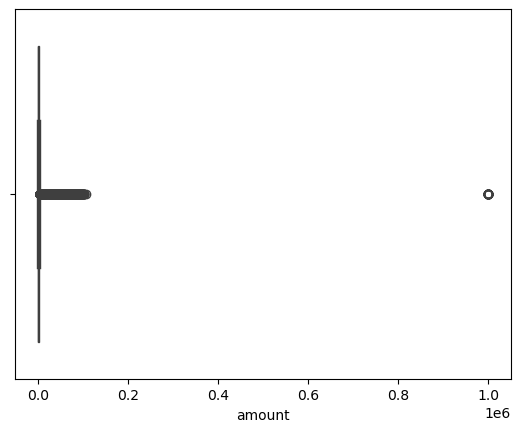

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(data = df_me ,x = 'amount')
plt.show()

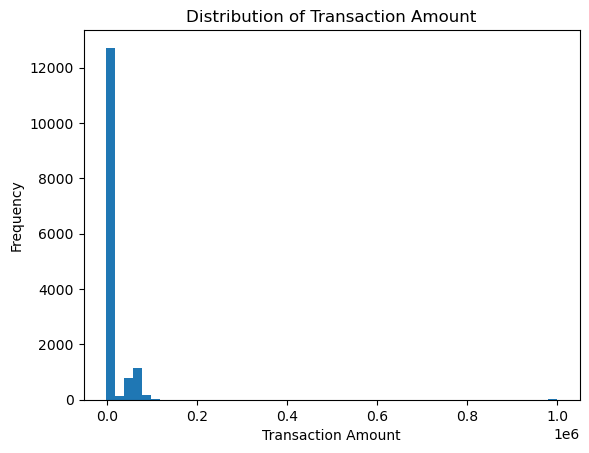

In [177]:
plt.hist(df_me['amount'],bins = 50)

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Transaction Amount')
plt.show()


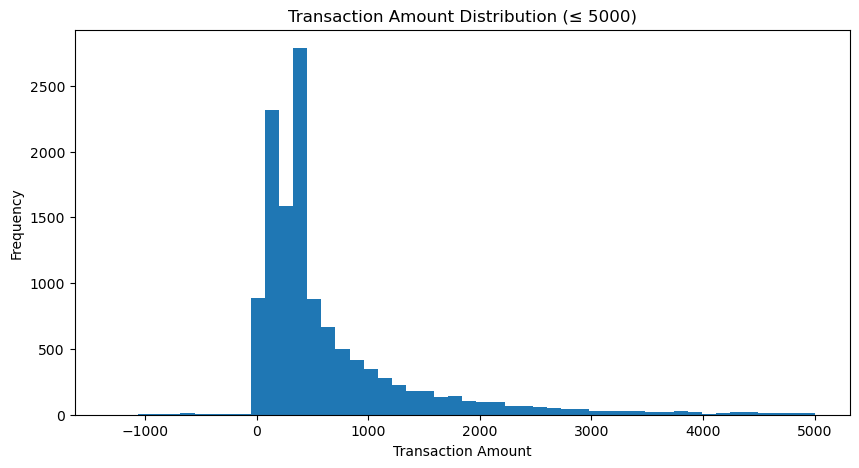

In [178]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_me[df_me['amount'] <= 5000]['amount'],
    bins=50
)

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution (≤ 5000)')

plt.show()

In [179]:
print("Negative:", (df_me['amount'] < 0).sum())
print("Above 10,000:", (df_me['amount'] > 10000).sum())
print("Above 100,000:", (df_me['amount'] > 100000).sum())

Negative: 53
Above 10,000: 2350
Above 100,000: 48


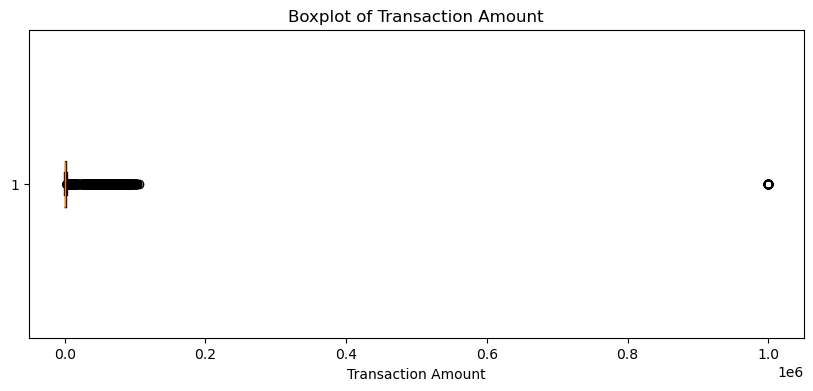

In [180]:
plt.figure(figsize=(10, 4))

plt.boxplot(df_me['amount'].dropna(), vert=False)

plt.xlabel('Transaction Amount')
plt.title('Boxplot of Transaction Amount')

plt.show()

In [170]:
(df_me['amount'] < 0).sum()

np.int64(53)

In [169]:
(df_me['amount'] > 100000).sum()

np.int64(48)

In [181]:
df_messy.nlargest(20, 'amount')[
    ['transaction_type', 'category', 'amount', 'payment_mode', 'location']
]

,transaction_type,category,amount,payment_mode,location
216,Expense,Food,999999.0,Card,Delhi
314,Expense,Food,999999.0,Card,Hyderabad
1407,Expense,Rent,999999.0,Card,Ahmedabad
1560,Expense,Rent,999999.0,Cash,Chennai
1581,Expense,Food,999999.0,UPI,Hyderabad
2073,Expense,Rent,999999.0,Bank Transfer,Lucknow
3036,Expense,Utilities,999999.0,Bank Transfer,Jaipur
3159,Expense,Others,999999.0,UPI,Delhi
3174,Expense,Utilities,999999.0,Card,Hyderabad
3430,Expense,Food,999999.0,UPI,Pune


In [183]:
df_me[df_me['amount'] < 0][
    ['transaction_type', 'category', 'amount', 'payment_mode', 'location']
].head(20)



,transaction_type,category,amount,payment_mode,location
290,Expense,travel,-786.0,bank transfer,Bengaluru
787,Expense,others,-72.0,upi,Pune
1098,Expense,rent,-606.0,upi,Delhi
1278,Expense,food,-754.0,bank transfer,Chennai
1682,Expense,food,-578.0,cash,Jaipur
1923,Expense,food,-970.0,upi,Bengaluru
2417,Expense,food,-667.0,upi,Hyderabad
2480,Expense,travel,-589.0,cash,Mumbai
2534,Expense,others,-635.0,upi,Unknown
2556,Expense,health,-32.0,cash,Mumbai


In [186]:
import numpy as np
df_me.loc[df_me['amount'] == 999999, 'amount'] = np.nan


In [188]:
(df_me['amount'] < 0).sum()

np.int64(53)

In [189]:
df_me.loc[df_me['amount'] < 0, 'amount'] = np.nan

In [190]:
category_median = df_me.groupby('category')['amount'].transform('median')

df_me['amount'] = df_me['amount'].fillna(category_median)

df_me['amount'] = df_me['amount'].fillna(536)

In [191]:
df_me['amount'].isna().sum()

np.int64(0)

In [192]:
print("Missing:", df_me['amount'].isna().sum())
print("Minimum:", df_me['amount'].min())
print("Maximum:", df_me['amount'].max())

Missing: 0
Minimum: 4.0
Maximum: 105562.0


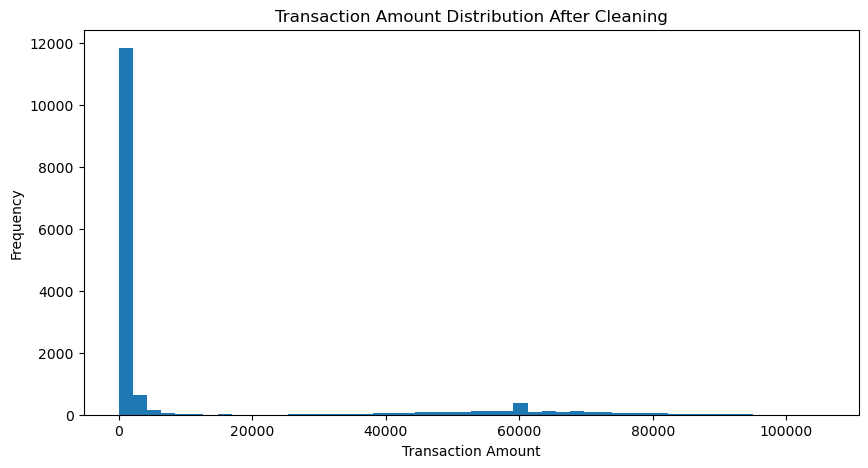

In [193]:
plt.figure(figsize=(10,5))

plt.hist(df_me['amount'], bins=50)

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Transaction Amount Distribution After Cleaning')

plt.show()

In [194]:
df_me.groupby('transaction_type')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
transaction_type,,,,,
Expense,12755,765.101999,404.5,4.0,34521.0
Income,2275,59650.218901,59637.5,580.5,105562.0


<Figure size 800x500 with 0 Axes>

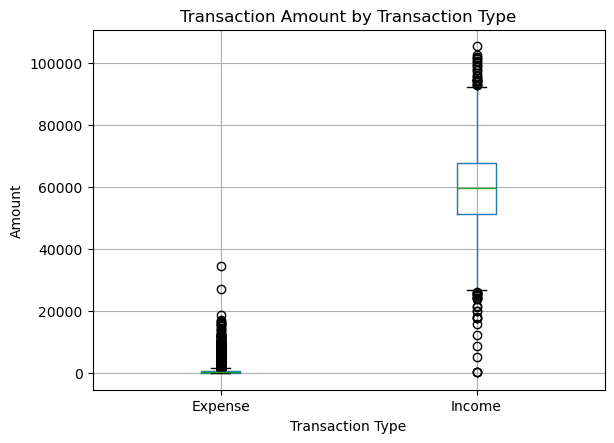

In [195]:
plt.figure(figsize=(8,5))

df_me.boxplot(
    column='amount',
    by='transaction_type'
)

plt.title('Transaction Amount by Transaction Type')
plt.suptitle('')
plt.xlabel('Transaction Type')
plt.ylabel('Amount')

plt.show()

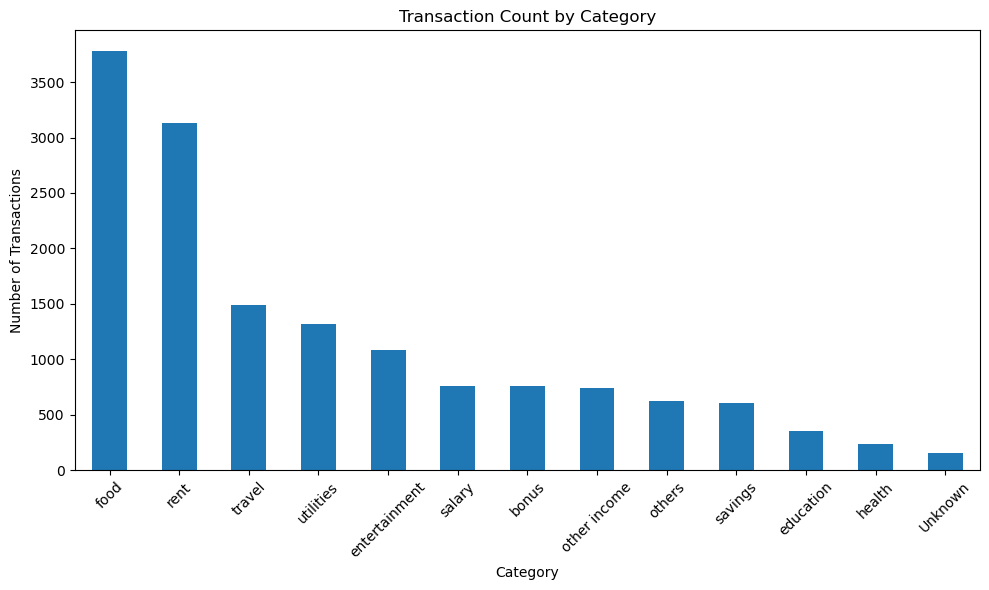

In [200]:
category_counts = df_me['category'].value_counts()
category_amount = (
    df_me.groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_counts.plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.title('Transaction Count by Category')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

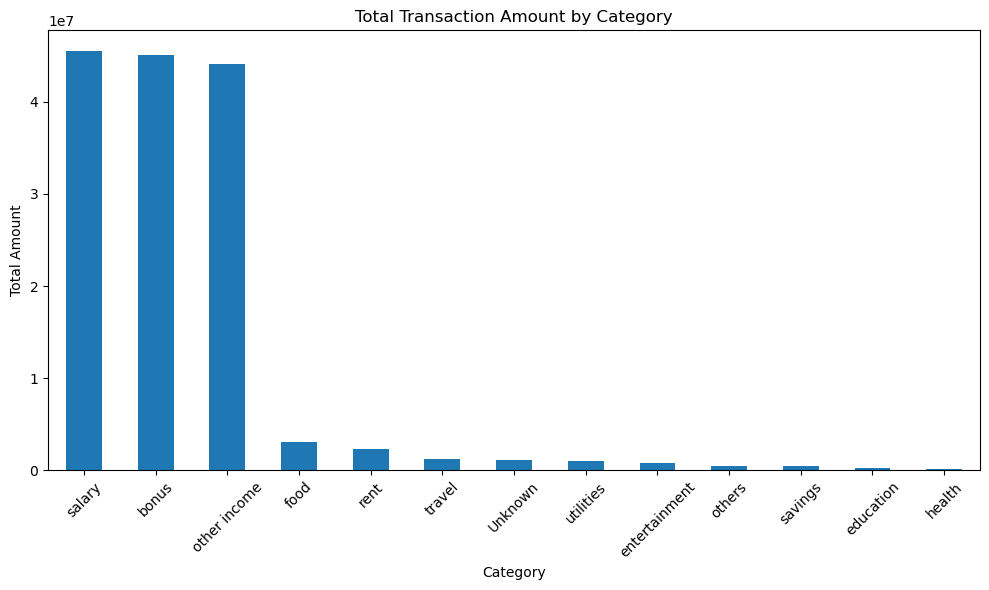

In [201]:
category_amount = (
    df_me.groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

category_amount.plot(kind='bar')

plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.title('Total Transaction Amount by Category')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

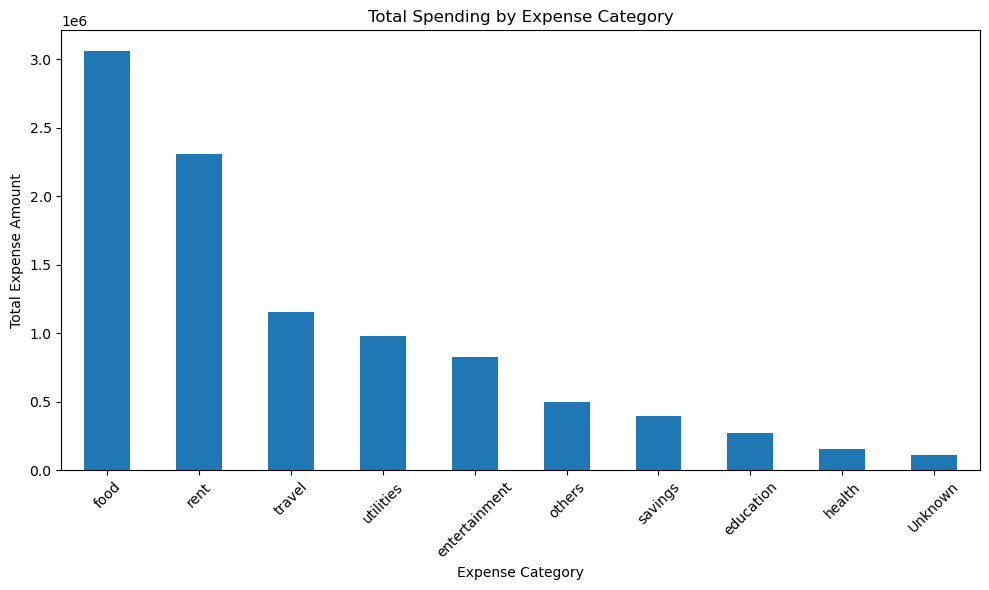

In [203]:
expense_df = df_me[
    df_me['transaction_type'] == 'Expense'
]

expense_category = (
    expense_df.groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

expense_category.plot(kind='bar')

plt.xlabel('Expense Category')
plt.ylabel('Total Expense Amount')
plt.title('Total Spending by Expense Category')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [204]:
user_income = (
    df_me[df_me['transaction_type'] == 'Income']
    .groupby('user_id')['amount']
    .sum()
)

user_expense = (
    df_me[df_me['transaction_type'] == 'Expense']
    .groupby('user_id')['amount']
    .sum()
)

user_summary = pd.DataFrame({
    'total_income': user_income,
    'total_expense': user_expense
}).fillna(0)

user_summary.head()

,total_income,total_expense
user_id,,
U001,1237277.5,59329.0
U002,1145284.0,41632.5
U003,1073424.5,51797.0
U004,542995.0,37392.0
U005,701587.5,38868.0


In [205]:
user_summary['savings'] = (
    user_summary['total_income'] -
    user_summary['total_expense']
)

user_summary.head()

,total_income,total_expense,savings
user_id,,,
U001,1237277.5,59329.0,1177948.5
U002,1145284.0,41632.5,1103651.5
U003,1073424.5,51797.0,1021627.5
U004,542995.0,37392.0,505603.0
U005,701587.5,38868.0,662719.5


In [207]:
user_summary['savings_ratio'] = (
    user_summary['savings'] / user_summary['total_income']
)
user_summary.head()

,total_income,total_expense,savings,savings_ratio
user_id,,,,
U001,1237277.5,59329.0,1177948.5,0.952049
U002,1145284.0,41632.5,1103651.5,0.963649
U003,1073424.5,51797.0,1021627.5,0.951746
U004,542995.0,37392.0,505603.0,0.931137
U005,701587.5,38868.0,662719.5,0.944600


In [209]:
transaction_count= df_me.groupby('user_id')['transaction_id'].count()
user_summary['transaction_count'] = transaction_count


In [211]:
avg_expense = (
    df_me[df_me['transaction_type'] == 'Expense']
    .groupby('user_id')['amount']
    .mean()
)

user_summary['avg_expense'] = avg_expense
user_summary.head(2)

,total_income,total_expense,savings,savings_ratio,transaction_count,avg_expense
user_id,,,,,,
U001,1237277.5,59329.0,1177948.5,0.952049,88,885.507463
U002,1145284.0,41632.5,1103651.5,0.963649,84,640.500000


In [212]:
user_summary.describe()

,total_income,total_expense,savings,savings_ratio,transaction_count,avg_expense
count,1.920000e+02,192.000000,1.920000e+02,192.000000,192.000000,192.000000
mean,7.067930e+05,50827.479167,6.559655e+05,0.920665,78.281250,766.016463
std,2.102796e+05,11963.711969,2.112960e+05,0.034379,7.805493,165.068875
min,2.516980e+05,24837.500000,1.983455e+05,0.735068,54.000000,480.438596
25%,5.709989e+05,42201.000000,5.145371e+05,0.905889,73.000000,645.185811
50%,6.787532e+05,49232.000000,6.344042e+05,0.926605,78.500000,745.568198
75%,8.349476e+05,58280.000000,7.830690e+05,0.945542,83.000000,856.577331
max,1.571616e+06,95824.000000,1.516658e+06,0.971039,99.000000,1306.838983


In [214]:
user_summary['expense_ratio'] = (
    user_summary['total_expense'] /
    user_summary['total_income']
)
user_summary[['savings_ratio', 'expense_ratio']].head()

,savings_ratio,expense_ratio
user_id,,
U001,0.952049,0.047951
U002,0.963649,0.036351
U003,0.951746,0.048254
U004,0.931137,0.068863
U005,0.944600,0.055400


In [216]:
user_summary[['expense_ratio']].describe()

,expense_ratio
count,192.000000
mean,0.079335
std,0.034379
min,0.028961
25%,0.054458
50%,0.073395
75%,0.094111
max,0.264932


In [227]:
corr = user_summary[
    [
        'total_income',
        'total_expense',
        'savings',
        'savings_ratio',
        'transaction_count',
        'avg_expense',
        'expense_ratio'
    ]
].corr()

corr

,total_income,total_expense,savings,savings_ratio,transaction_count,avg_expense,expense_ratio
total_income,1.000000,-0.056717,0.998401,0.729514,0.371532,-0.031279,-0.729514
total_expense,-0.056717,1.000000,-0.113064,-0.602494,0.374643,0.868479,0.602494
savings,0.998401,-0.113064,1.000000,0.760118,0.348532,-0.080302,-0.760118
savings_ratio,0.729514,-0.602494,0.760118,1.000000,0.074701,-0.532529,-1.000000
transaction_count,0.371532,0.374643,0.348532,0.074701,1.000000,-0.066663,-0.074701
avg_expense,-0.031279,0.868479,-0.080302,-0.532529,-0.066663,1.000000,0.532529
expense_ratio,-0.729514,0.602494,-0.760118,-1.000000,-0.074701,0.532529,1.000000


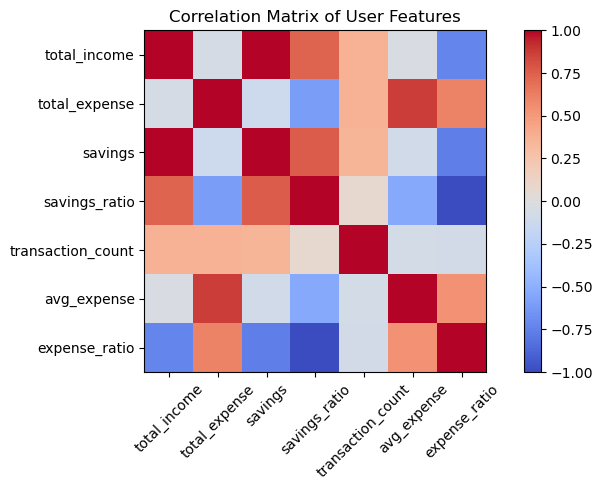

In [228]:
plt.figure(figsize=(8,5))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix of User Features')

plt.tight_layout()
plt.show()

In [229]:
features = [
    'total_income',
    'total_expense',
    'transaction_count',
    'avg_expense',
    'expense_ratio'
]

X = user_summary[features]

X.head()

,total_income,total_expense,transaction_count,avg_expense,expense_ratio
user_id,,,,,
U001,1237277.5,59329.0,88,885.507463,0.047951
U002,1145284.0,41632.5,84,640.500000,0.036351
U003,1073424.5,51797.0,81,809.328125,0.048254
U004,542995.0,37392.0,59,747.840000,0.068863
U005,701587.5,38868.0,79,571.588235,0.055400


In [230]:
X.isnull().sum()

total_income         0
total_expense        0
transaction_count    0
avg_expense          0
expense_ratio        0
dtype: int64

In [235]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled[:5]

array([[ 2.52935353,  0.71246676,  1.24837196,  0.72577822, -0.91528401],
       [ 2.09072796, -0.77058177,  0.73457257, -0.76237638, -1.25358416],
       [ 1.74810143,  0.08125033,  0.34922303,  0.26307137, -0.90645531],
       [-0.78098966, -1.12595528, -2.47667364, -0.1104023 , -0.30543207],
       [-0.02481966, -1.00225966,  0.09232333, -1.18094061, -0.69804791]])

In [244]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You c

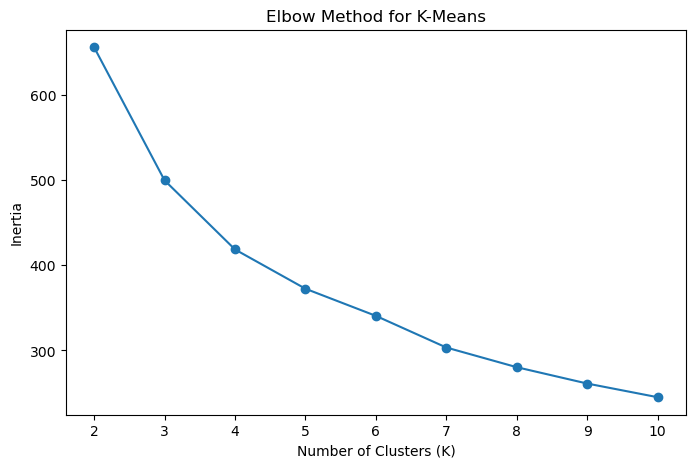

In [245]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means')

plt.show()

In [248]:
Kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

user_summary['cluster'] = Kmeans.fit_predict(X_scaled)

E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [249]:
user_summary['cluster'].value_counts().sort_index()

cluster
0    59
1    48
2    61
3    24
Name: count, dtype: int64

In [250]:
cluster_profile = user_summary.groupby('cluster')[
    [
        'total_income',
        'total_expense',
        'transaction_count',
        'avg_expense',
        'expense_ratio'
    ]
].mean()

cluster_profile

,total_income,total_expense,transaction_count,avg_expense,expense_ratio
cluster,,,,,
0,911143.262712,53135.720339,84.796610,766.157978,0.060536
1,524697.677083,52284.895833,76.750000,774.726326,0.103208
2,698352.295082,39073.016393,73.295082,641.174754,0.058104
3,590075.708333,72114.145833,78.000000,1065.554855,0.131768


In [251]:
user_summary['cluster'].value_counts().sort_index()

cluster
0    59
1    48
2    61
3    24
Name: count, dtype: int64

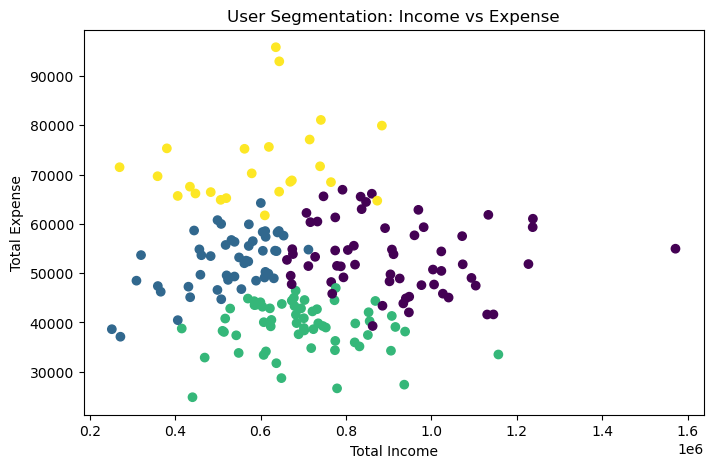

In [252]:
plt.figure(figsize=(8, 5))

plt.scatter(
    user_summary['total_income'],
    user_summary['total_expense'],
    c=user_summary['cluster']
)

plt.xlabel('Total Income')
plt.ylabel('Total Expense')
plt.title('User Segmentation: Income vs Expense')

plt.show()

In [253]:
cluster_names = {
    0: 'High Income - Low Spending',
    1: 'Lower Income - Higher Spending',
    2: 'Moderate Income - Low Spending',
    3: 'High Spending'
}

user_summary['cluster_name'] = user_summary['cluster'].map(cluster_names)

In [256]:
user_summary['cluster_name'].value_counts()

cluster_name
Moderate Income - Low Spending    61
High Income - Low Spending        59
Lower Income - Higher Spending    48
High Spending                     24
Name: count, dtype: int64

In [257]:
user_summary.groupby('cluster_name')[
    ['total_income', 'total_expense', 'transaction_count',
     'avg_expense', 'expense_ratio']
].mean().round(2)

,total_income,total_expense,transaction_count,avg_expense,expense_ratio
cluster_name,,,,,
High Income - Low Spending,911143.26,53135.72,84.80,766.16,0.06
High Spending,590075.71,72114.15,78.00,1065.55,0.13
Lower Income - Higher Spending,524697.68,52284.90,76.75,774.73,0.10
Moderate Income - Low Spending,698352.30,39073.02,73.30,641.17,0.06


In [258]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, user_summary['cluster'])

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2663203558773582


In [260]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Silhouette Score={score:.3f}")

E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=2, Silhouette Score=0.304
K=3, Silhouette Score=0.278


E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=4, Silhouette Score=0.266
K=5, Silhouette Score=0.242


E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K=6, Silhouette Score=0.236
K=7, Silhouette Score=0.240
K=8, Silhouette Score=0.243


E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


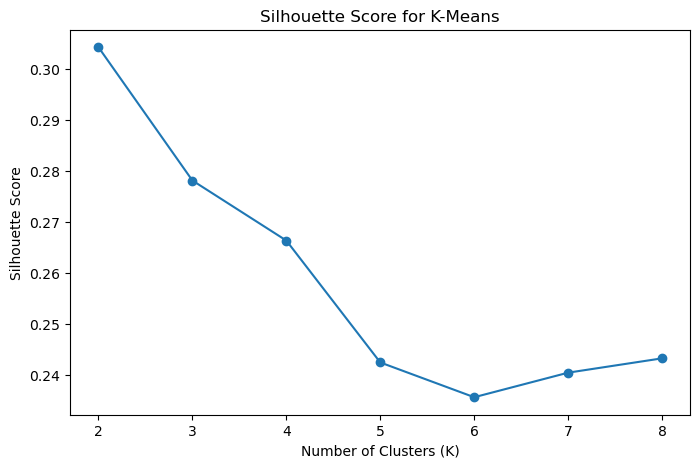

In [261]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 9), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')

plt.show()

In [262]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

user_summary['cluster'] = final_kmeans.fit_predict(X_scaled)

E:\ANAC\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [263]:
cluster_names = {
    0: 'High Income - Low Spending',
    1: 'Lower Income - Higher Spending',
    2: 'Moderate Income - Low Spending',
    3: 'High Spending'
}

user_summary['cluster_name'] = user_summary['cluster'].map(cluster_names)

In [264]:
cluster_profile = (
    user_summary
    .groupby(['cluster', 'cluster_name'])[
        ['total_income',
         'total_expense',
         'transaction_count',
         'avg_expense',
         'expense_ratio']
    ]
    .mean()
    .round(2)
)

cluster_profile

,,total_income,total_expense,transaction_count,avg_expense,expense_ratio
cluster,cluster_name,,,,,
0,High Income - Low Spending,911143.26,53135.72,84.80,766.16,0.06
1,Lower Income - Higher Spending,524697.68,52284.90,76.75,774.73,0.10
2,Moderate Income - Low Spending,698352.30,39073.02,73.30,641.17,0.06
3,High Spending,590075.71,72114.15,78.00,1065.55,0.13


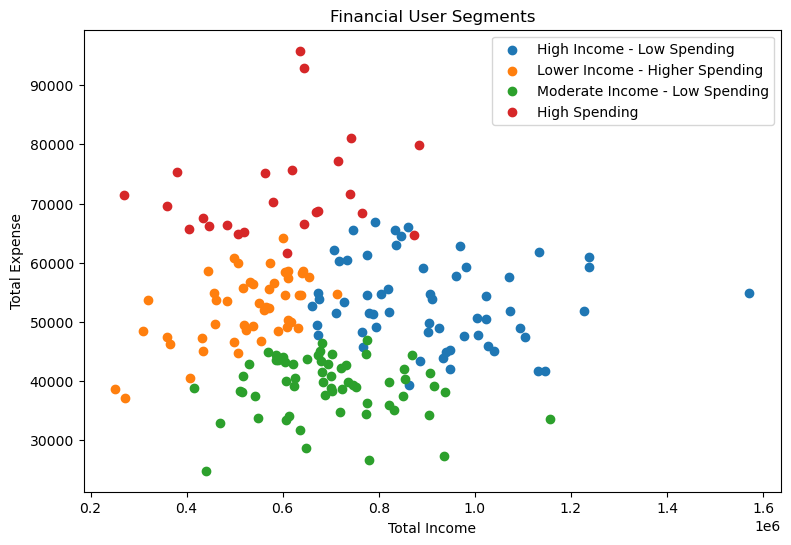

In [265]:
plt.figure(figsize=(9, 6))

for cluster in sorted(user_summary['cluster'].unique()):
    data = user_summary[user_summary['cluster'] == cluster]

    plt.scatter(
        data['total_income'],
        data['total_expense'],
        label=cluster_names[cluster]
    )

plt.xlabel('Total Income')
plt.ylabel('Total Expense')
plt.title('Financial User Segments')
plt.legend()
plt.show()

In [266]:
cluster_names = {
    0: 'High Income - Low Spending',
    1: 'Lower Income - Higher Spending',
    2: 'Moderate Income - Low Spending',
    3: 'High Expense Behavior'
}

In [272]:
import joblib

print(joblib.dump(scaler, 'scaler.pkl'))
print(joblib.dump(final_kmeans, 'kmeans_model.pkl'))

['scaler.pkl']
['kmeans_model.pkl']


In [268]:
features = [
    'total_income',
    'total_expense',
    'transaction_count',
    'avg_expense',
    'expense_ratio'
]

In [269]:
def predict_segment(total_income, total_expense,
                    transaction_count, avg_expense,
                    expense_ratio):

    new_data = pd.DataFrame([{
        'total_income': total_income,
        'total_expense': total_expense,
        'transaction_count': transaction_count,
        'avg_expense': avg_expense,
        'expense_ratio': expense_ratio
    }])

    new_scaled = scaler.transform(new_data)

    cluster = final_kmeans.predict(new_scaled)[0]

    return cluster_names[cluster]

In [270]:
predict_segment(
    total_income=600000,
    total_expense=70000,
    transaction_count=78,
    avg_expense=1000,
    expense_ratio=0.12
)

'High Expense Behavior'

In [273]:
user_summary.columns

Index(['total_income', 'total_expense', 'savings', 'savings_ratio',
       'transaction_count', 'avg_expense', 'expense_ratio', 'cluster',
       'cluster_name'],
      dtype='object')

In [274]:
for i in range(5):
    row = user_summary.iloc[i]

    prediction = predict_segment(
        row['total_income'],
        row['total_expense'],
        row['transaction_count'],
        row['avg_expense'],
        row['expense_ratio']
    )

    print(
        f"Actual: {row['cluster_name']} | "
        f"Predicted: {prediction}"
    )

Actual: High Income - Low Spending | Predicted: High Income - Low Spending
Actual: High Income - Low Spending | Predicted: High Income - Low Spending
Actual: High Income - Low Spending | Predicted: High Income - Low Spending
Actual: Moderate Income - Low Spending | Predicted: Moderate Income - Low Spending
Actual: Moderate Income - Low Spending | Predicted: Moderate Income - Low Spending


In [275]:
cluster_insights = {
    'High Income - Low Spending':
        'You have a strong income level with relatively low spending. Your spending pattern indicates good financial control.',

    'Lower Income - Higher Spending':
        'Your expenses take a relatively larger share of your income. Consider monitoring discretionary spending.',

    'Moderate Income - Low Spending':
        'Your spending is relatively controlled compared with your income. Continue maintaining this spending pattern.',

    'High Expense Behavior':
        'Your expense level and expense ratio are relatively high. Review your major spending categories and look for opportunities to reduce unnecessary expenses.'
}

In [276]:
predicted_segment = predict_segment(
    600000,
    70000,
    78,
    1000,
    0.12
)

print("Segment:", predicted_segment)
print("Insight:", cluster_insights[predicted_segment])

Segment: High Expense Behavior
Insight: Your expense level and expense ratio are relatively high. Review your major spending categories and look for opportunities to reduce unnecessary expenses.


In [277]:
def financial_profile(
    total_income,
    total_expense,
    transaction_count,
    avg_expense
):
    
    expense_ratio = total_expense / total_income

    new_data = pd.DataFrame([{
        'total_income': total_income,
        'total_expense': total_expense,
        'transaction_count': transaction_count,
        'avg_expense': avg_expense,
        'expense_ratio': expense_ratio
    }])

    new_scaled = scaler.transform(new_data)

    cluster = final_kmeans.predict(new_scaled)[0]

    segment = cluster_names[cluster]
    insight = cluster_insights[segment]

    return {
        'segment': segment,
        'expense_ratio': round(expense_ratio, 3),
        'insight': insight
    }

In [278]:
result = financial_profile(
    total_income=600000,
    total_expense=70000,
    transaction_count=78,
    avg_expense=1000
)

print(result)

{'segment': 'High Expense Behavior', 'expense_ratio': 0.117, 'insight': 'Your expense level and expense ratio are relatively high. Review your major spending categories and look for opportunities to reduce unnecessary expenses.'}


In [281]:
def get_user_summary(user_id):

    user_data = df_me[df_me['user_id'] == user_id]

    total_income = user_data.loc[
        user_data['transaction_type'] == 'Income',
        'amount'
    ].sum()

    total_expense = user_data.loc[
        user_data['transaction_type'] == 'Expense',
        'amount'
    ].sum()

    transaction_count = len(user_data)

    avg_expense = user_data.loc[
        user_data['transaction_type'] == 'Expense',
        'amount'
    ].mean()

    savings = total_income - total_expense

    expense_ratio = total_expense / total_income

    top_category = (
        user_data.loc[
            user_data['transaction_type'] == 'Expense'
        ]
        .groupby('category')['amount']
        .sum()
        .idxmax()
    )

    return {
        'user_id': user_id,
        'total_income': total_income,
        'total_expense': total_expense,
        'savings': savings,
        'transaction_count': transaction_count,
        'avg_expense': avg_expense,
        'expense_ratio': expense_ratio,
        'top_category': top_category
    }

In [282]:
profile = get_user_summary('U001')

profile

{'user_id': 'U001',
 'total_income': np.float64(1237277.5),
 'total_expense': np.float64(59329.0),
 'savings': np.float64(1177948.5),
 'transaction_count': 88,
 'avg_expense': np.float64(885.5074626865671),
 'expense_ratio': np.float64(0.047951247800109516),
 'top_category': 'food'}

In [283]:
def analyze_user(user_id):

    profile = get_user_summary(user_id)

    result = financial_profile(
        total_income=profile['total_income'],
        total_expense=profile['total_expense'],
        transaction_count=profile['transaction_count'],
        avg_expense=profile['avg_expense']
    )

    profile['segment'] = result['segment']
    profile['insight'] = result['insight']

    return profile

In [284]:
analyze_user('U001')

{'user_id': 'U001',
 'total_income': np.float64(1237277.5),
 'total_expense': np.float64(59329.0),
 'savings': np.float64(1177948.5),
 'transaction_count': 88,
 'avg_expense': np.float64(885.5074626865671),
 'expense_ratio': np.float64(0.047951247800109516),
 'top_category': 'food',
 'segment': 'High Income - Low Spending',
 'insight': 'You have a strong income level with relatively low spending. Your spending pattern indicates good financial control.'}

In [285]:
def analyze_finances(total_income, total_expense,
                     transaction_count, avg_expense):

    savings = total_income - total_expense
    expense_ratio = total_expense / total_income

    result = financial_profile(
        total_income,
        total_expense,
        transaction_count,
        avg_expense
    )

    return {
        'total_income': round(float(total_income), 2),
        'total_expense': round(float(total_expense), 2),
        'savings': round(float(savings), 2),
        'transaction_count': int(transaction_count),
        'avg_expense': round(float(avg_expense), 2),
        'expense_ratio': round(float(expense_ratio * 100), 2),
        'segment': result['segment'],
        'insight': result['insight']
    }

In [286]:
result = analyze_finances(
    total_income=60000,
    total_expense=12000,
    transaction_count=45,
    avg_expense=800
)

result

{'total_income': 60000.0,
 'total_expense': 12000.0,
 'savings': 48000.0,
 'transaction_count': 45,
 'avg_expense': 800.0,
 'expense_ratio': 20.0,
 'segment': 'Lower Income - Higher Spending',
 'insight': 'Your expenses take a relatively larger share of your income. Consider monitoring discretionary spending.'}

In [288]:
!pip install streamlit

In [289]:
import streamlit as st

st.title("💰 Personal Finance AI")

st.write(
    "Enter your financial information to analyze your spending behavior."
)

total_income = st.number_input(
    "Total Income",
    min_value=0.0
)

total_expense = st.number_input(
    "Total Expenses",
    min_value=0.0
)

transaction_count = st.number_input(
    "Number of Transactions",
    min_value=1,
    step=1
)

avg_expense = st.number_input(
    "Average Expense",
    min_value=0.0
)

if st.button("Analyze My Finances"):

    result = analyze_finances(
        total_income,
        total_expense,
        transaction_count,
        avg_expense
    )

    st.subheader("Your Financial Profile")

    st.write("Segment:", result['segment'])
    st.write("Savings:", result['savings'])
    st.write("Expense Ratio:", result['expense_ratio'], "%")
    st.write("Insight:", result['insight'])

2026-08-26 20:38:15.788 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.815 
  command:

    streamlit run E:\ANAC\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-26 20:38:16.816 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.825 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-26 20:38:16.828 Thread 'MainThread': missing ScriptRunCo

In [293]:
import pandas as pd
import joblib

# Load trained models
scaler = joblib.load("scaler.pkl")
kmeans = joblib.load("kmeans_model.pkl")


cluster_names = {
    0: "High Income - Low Spending",
    1: "Lower Income - Higher Spending",
    2: "Moderate Income - Low Spending",
    3: "High Expense Behavior"
}


cluster_insights = {
    "High Income - Low Spending":
        "You have a strong income level with relatively low spending. "
        "Your spending pattern indicates good financial control.",

    "Lower Income - Higher Spending":
        "Your expenses take a relatively larger share of your income. "
        "Consider monitoring discretionary spending.",

    "Moderate Income - Low Spending":
        "Your spending is relatively controlled compared with your income. "
        "Continue maintaining this spending pattern.",

    "High Expense Behavior":
        "Your expense level and expense ratio are relatively high. "
        "Review your major spending categories and look for opportunities "
        "to reduce unnecessary expenses."
}


def analyze_finances(
    total_income,
    total_expense,
    transaction_count,
    avg_expense
):

    expense_ratio = total_expense / total_income

    new_data = pd.DataFrame([{
        "total_income": total_income,
        "total_expense": total_expense,
        "transaction_count": transaction_count,
        "avg_expense": avg_expense,
        "expense_ratio": expense_ratio
    }])

    new_scaled = scaler.transform(new_data)

    cluster = kmeans.predict(new_scaled)[0]

    segment = cluster_names[cluster]
    insight = cluster_insights[segment]

    savings = total_income - total_expense

    return {
        "total_income": round(float(total_income), 2),
        "total_expense": round(float(total_expense), 2),
        "savings": round(float(savings), 2),
        "transaction_count": int(transaction_count),
        "avg_expense": round(float(avg_expense), 2),
        "expense_ratio": round(float(expense_ratio * 100), 2),
        "segment": segment,
        "insight": insight
    }

In [296]:
def analyze_finances(total_income, total_expense,
                     transaction_count, avg_expense):

    expense_ratio = total_expense / total_income

    new_data = pd.DataFrame([{
        "total_income": total_income,
        "total_expense": total_expense,
        "transaction_count": transaction_count,
        "avg_expense": avg_expense,
        "expense_ratio": expense_ratio
    }])

    new_scaled = scaler.transform(new_data)

    cluster = kmeans.predict(new_scaled)[0]

    segment = cluster_names[cluster]

    savings = total_income - total_expense

    return {
        "total_income": round(float(total_income), 2),
        "total_expense": round(float(total_expense), 2),
        "savings": round(float(savings), 2),
        "transaction_count": int(transaction_count),
        "avg_expense": round(float(avg_expense), 2),
        "expense_ratio": round(float(expense_ratio * 100), 2),
        "segment": segment
    }

In [297]:
analyze_finances(
    total_income=60000,
    total_expense=12000,
    transaction_count=45,
    avg_expense=800
)

{'total_income': 60000.0,
 'total_expense': 12000.0,
 'savings': 48000.0,
 'transaction_count': 45,
 'avg_expense': 800.0,
 'expense_ratio': 20.0,
 'segment': 'Lower Income - Higher Spending'}